# 03 - XGBoost Tuning, Evaluation, SHAP & Fairness

In [1]:
import sys; sys.path.append('..')
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import pandas as pd
from src.train_xgboost import train
model, best_cv, best_params = train()
best_params

XGBoost CV AUROC=0.7225
Best params: {'clf__learning_rate': 0.025, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__reg_alpha': 0.5, 'clf__reg_lambda': 1}


{'clf__learning_rate': 0.025,
 'clf__max_depth': 3,
 'clf__n_estimators': 100,
 'clf__reg_alpha': 0.5,
 'clf__reg_lambda': 1}

In [2]:
from src.train_logreg import train as train_lr
_, _, lr_cv = train_lr()
from src.evaluate import evaluate_all
metrics, probs = evaluate_all({'Logistic Regression (best)': lr_cv, 'XGBoost': best_cv})
metrics

Ridge       CV AUROC=0.7312 (C=0.03162)


Lasso       CV AUROC=0.7325 (C=0.1)


ElasticNet  CV AUROC=0.7326 (C=0.03162)
Best baseline: ElasticNet


,model,cv_auroc,test_auroc,auroc_95ci,test_auprc,brier,threshold,f1
0,Logistic Regression (best),0.7326,0.7022,"[0.652, 0.746]",0.2985,0.1206,0.1595,0.3671
1,XGBoost,0.7225,0.6827,"[0.631, 0.733]",0.2904,0.1212,0.1530,0.3473


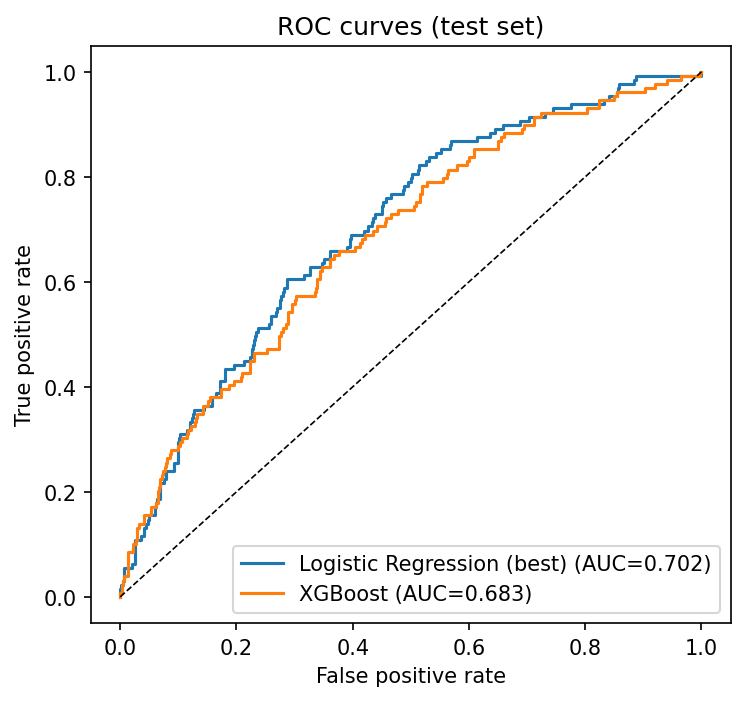

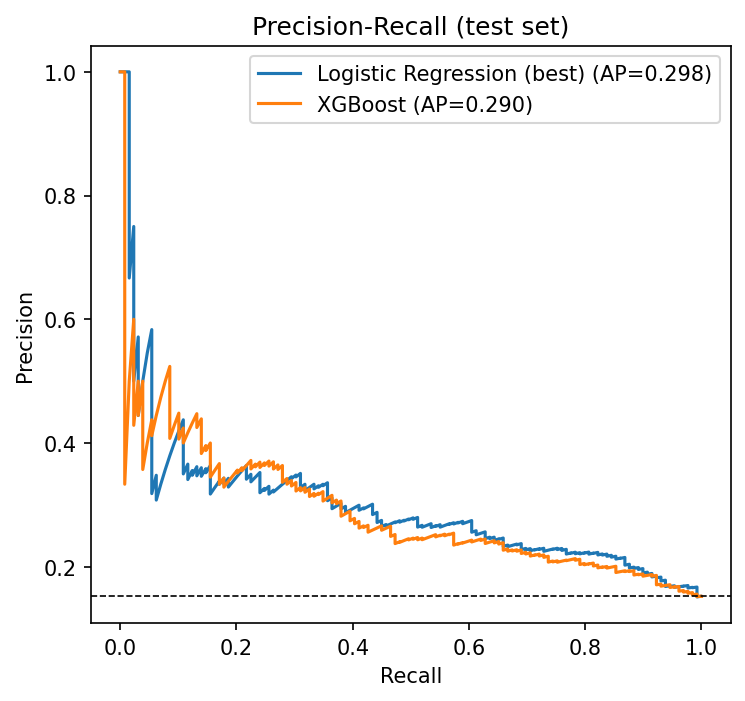

In [3]:
from IPython.display import Image, display
for f in ['roc_curves','pr_curves']: display(Image(f'../results/figures/{f}.png', width=420))

## Feature importance (SHAP)

In [4]:
from src.evaluate import shap_importance
shap_importance().round(4)

age                0.4380
cigsPerDay         0.1187
male               0.1108
pulse_pressure     0.0914
sysBP              0.0739
map_bp             0.0679
prevalentHyp       0.0483
glucose            0.0468
totChol            0.0433
BMI                0.0291
diaBP              0.0144
heartRate          0.0142
education          0.0053
BPMeds             0.0041
currentSmoker      0.0038
diabetes           0.0024
prevalentStroke    0.0016
dtype: float32

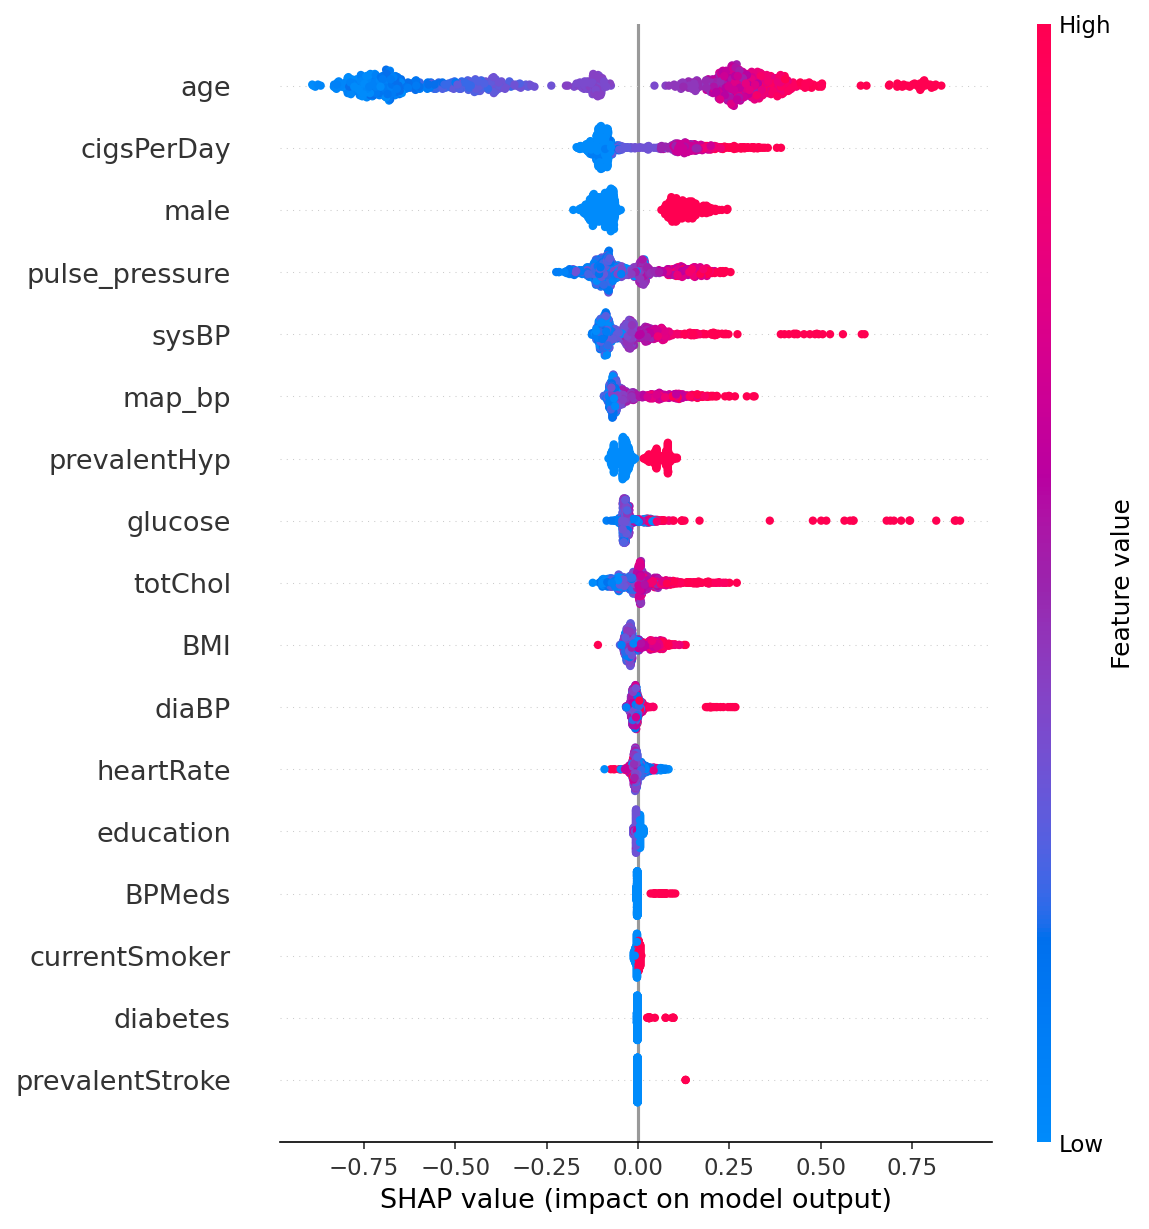

In [5]:
display(Image('../results/figures/shap_summary.png', width=520))

## Fairness: performance across sex and age groups

In [6]:
from src.fairness import fairness_analysis
from src.data_preprocessing import get_split
_, Xte, _, yte = get_split()
fairness_analysis(Xte, yte, probs['XGBoost'], 'XGBoost').round(3)

,attribute,group,n,incidence,mean_pred_risk,auroc,auprc,calibration_gap
0,age_group,45-54,291,0.141,0.151,0.641,0.240,0.011
1,age_group,55-64,221,0.235,0.217,0.650,0.372,-0.018
2,age_group,65+,37,0.243,0.306,0.599,0.430,0.063
3,age_group,<45,299,0.090,0.075,0.634,0.164,-0.015
4,sex,Female,482,0.108,0.133,0.667,0.204,0.025
5,sex,Male,366,0.210,0.168,0.670,0.375,-0.042


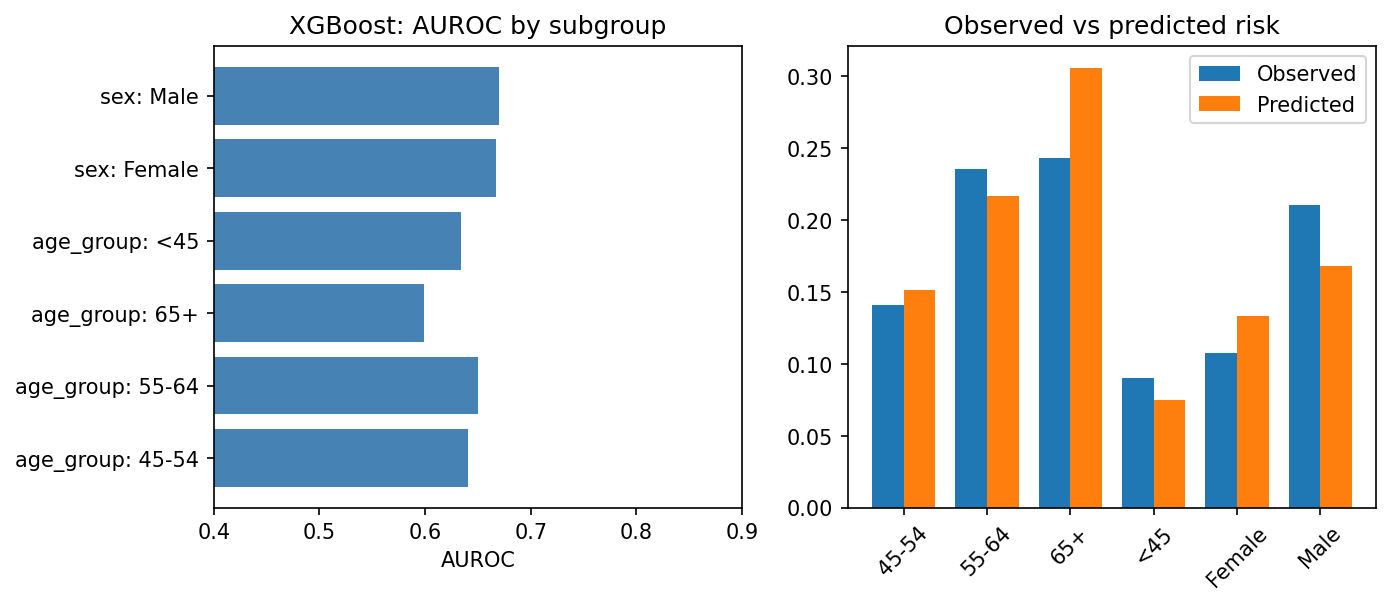

In [7]:
display(Image('../results/figures/fairness_xgboost.png'))

**Discussion:** With ~4k rows, XGBoost does not clearly beat regularised logistic regression (confidence intervals overlap) - consistent with the literature the Stanford paper cites (Rajkomar et al., 2018). Subgroup AUROC gaps and over-prediction for the 65+ group highlight the fairness concerns raised in the paper.